---------- TASK 1A ----------

We start out program with gaining a basic understanding of the dataset before preprocessing and model building. This is commonly referred to as Exploratory Data Analysis. 

In [13]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Load data
df = pd.read_csv("reviews.csv")

# 3. Quick look at data
print(df.head())
print(df.info())

                              review_id  rating  \
0  981e465b-d3ba-4632-9c60-25051efac38a       5   
1  964d3555-9429-4c20-8127-ce3c71ce9273       5   
2  6c28859f-1554-4ca1-9aa8-9d66f204be0a       5   
3  a7efafc3-5871-4020-a398-9cc12cb4072a       5   
4  de142b31-a5ad-446f-b7c8-51b264728478       4   

                                         review_text       review_date  \
0                                          It's good   11/22/2025 1:19   
1  WhatsApp not working well always shows offline...  11/24/2025 20:03   
2  Oppo not corresponding, share with me the offi...   11/25/2025 6:26   
3  Excellent app, great communication super conne...  11/25/2025 18:09   
4       simply the ɓest for chat and calls.i love it   11/24/2025 1:10   

   helpful  
0        0  
1        0  
2        0  
3        0  
4        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6210 entries, 0 to 6209
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       -----

Check for missing values. We found this necessary because the missing text prevents feature extraction, and the missing ratings also prevent supervised learning. Keeping incomplete rows could possibly cause errors during the modeling, and therefore we decided it was for the best. 

In [14]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Drop rows with missing review_text or score
df = df.dropna(subset=['review_text', 'rating'])

Missing values per column:
review_id      0
rating         0
review_text    0
review_date    0
helpful        0
dtype: int64


To understand the data even better, we created two new features which would allow us to examine variation in review length, distribution of word count and whether extremely short or long reviews exist in the document.

Understanding this variation is important because text length may influence how informative the review is. 

In [15]:
# Add columns for text length and word count
df['text_length'] = df['review_text'].apply(len)
df['word_count'] = df['review_text'].apply(lambda x: len(x.split()))

# Print summary statistics
print("Text length statistics:")
print(df['text_length'].describe())

print("\nWord count statistics:")
print(df['word_count'].describe())

Text length statistics:
count    6210.000000
mean       93.598390
std       130.661464
min         3.000000
25%        22.000000
50%        44.000000
75%       100.000000
max      1260.000000
Name: text_length, dtype: float64

Word count statistics:
count    6210.000000
mean       15.456200
std        19.791963
min         1.000000
25%         4.000000
50%         7.000000
75%        18.750000
max       105.000000
Name: word_count, dtype: float64


Visualization. 

Rating distribution
We plotted the distribution of ratings using a bar chart to help us determine whether the dataset is balanced or imbalanced and whether certain ratings dominate the dataset.

The rating distribution provides insight into whether the dataset is balanced across rating classes. If certain ratings dominate, the dataset is imbalanced, which may bias the model toward predicting the majority class. This affects both model selection and evaluation strategy. Additionally, the distribution offers insight into user behavior and the overall sentiment structure of the dataset, which influences the difficulty of the prediction task.

This dataset shows us that there is many pleased customers as most of the reviews got 5 stars, but also many dissappointed customers because many revies got 1 star. 

The second diagram shows us that most of the reviews are short. (Between 0-100 words) 

The last diagram shows us that most of the reviews are short, and contains mostly 1-10 words. Some go up to 20 words, and very few go up too 100 words.

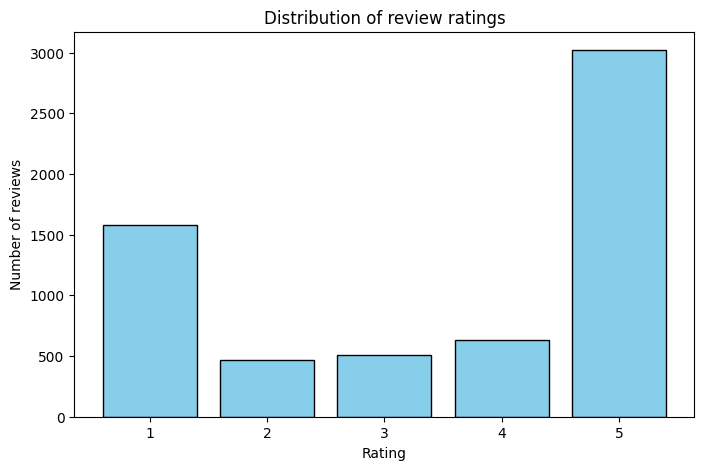

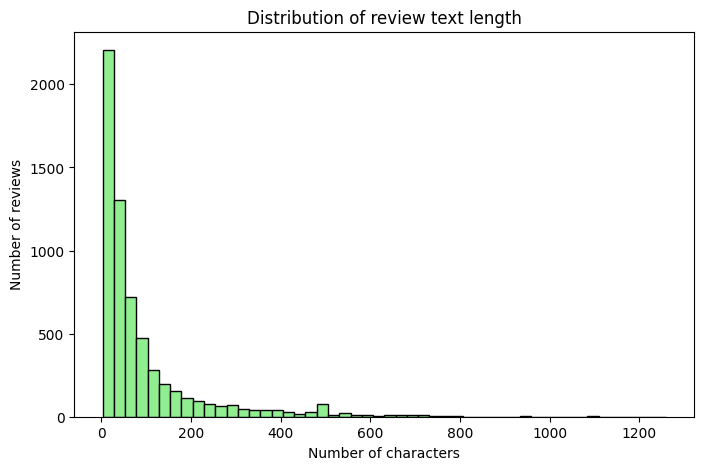

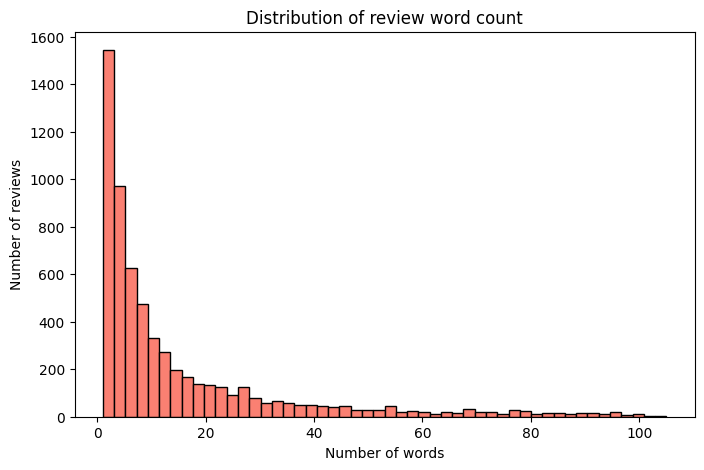

In [16]:

# Rating distribution
rating_counts = df['rating'].value_counts().sort_index()
plt.figure(figsize=(8,5))
plt.bar(rating_counts.index, rating_counts.values, color='skyblue', edgecolor='black')
plt.title("Distribution of review ratings")
plt.xlabel("Rating")
plt.ylabel("Number of reviews")
plt.show()

# Add columns for text length and word count
df['text_length'] = df['review_text'].apply(len)
df['word_count'] = df['review_text'].apply(lambda x: len(x.split()))

# Text length histogram
plt.figure(figsize=(8,5))
plt.hist(df['text_length'], bins=50, color='lightgreen', edgecolor='black');  # <-- add semicolon
plt.title("Distribution of review text length")
plt.xlabel("Number of characters")
plt.ylabel("Number of reviews")
plt.show()

# Word count histogram
plt.figure(figsize=(8,5))
plt.hist(df['word_count'], bins=50, color='salmon', edgecolor='black');  # <-- add semicolon
plt.title("Distribution of review word count")
plt.xlabel("Number of words")
plt.ylabel("Number of reviews")
plt.show()

TF-IDF Preprocessing. 

Lowecasing ensures that words like “Good” and “good” are treated as the same token. This reduces vocabulary size and improves consistency.

Then we trnsformed the text into numerical format features using TF-IDF. This converts unstructured text into a structured numerical format suitable for machine learning. We decided to use TF-IDF because it assigns higher importance to informative words, and reduces the influence of very common words. It also provides a sparse but meaningful feature representation.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Lowercase all text
df['clean_text'] = df['review_text'].str.lower()

# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

# Fit and transform text
X = tfidf.fit_transform(df['clean_text'])

# Labels
y = df['rating']

print("TF-IDF features shape:", X.shape)

TF-IDF features shape: (6210, 5000)


6210 = Antall rowss i dokumentet vårt = number of reviews 

5000 = Antall columns i dokumentet = number of TF-IDF features (words) you kept. 

The TF-IDF vectorizer transforms the text into a sparse matrix with shape (6210, 5000), meaning we have 6210 reviews and 5000 word features. Sparse matrices store mostly zeros efficiently, so printing the full matrix isn’t necessary.

Now that we have a good understanding of what the data contains. The next step is performing data cleaning to reduce the amount of unessecary and useless data considering task b.

Data Cleaning

In [18]:
#Data cleaning

import re #Re is used for regex/pattern search, e.g. finding words.
import pandas as pd #Pandas is used to read cvs files and work with tables / Data Frame. We'll call it pd.

path_in = "reviews.csv" #defining the file we're going to read.
df = pd.read_csv(path_in) #reading the csv file and saving it to df (Data Frame)

if "review_text" not in df.columns: #checking if "review_text" is a column in the file.
    raise ValueError(f"Fant ikke 'review_text'. Kolonner: {list(df.columns)}") #stopping the program and showing the actual columns.

df = df.dropna(subset=["review_text"]).copy() #removing rows where "review_text" column is empty.
df["review_text"] = df["review_text"].astype(str) #Making sure everything in "review_text" column is a string, converting other datatypes
df = df[df["review_text"].str.strip() != ""] #removes rows where review_text only contains spaces

df = df.drop_duplicates(subset=["review_text"]) #Removes duplicates

#Finds part of a string that can be words
def word_count(text):
    return len(re.findall(r"[a-zA-Z0-9']+", text)) #Returns number of matches / words

df = df[df["review_text"].apply(word_count) >= 3] #Removes rows with 3 or less words

#Basic text cleaning
def clean_text(text):
    text = text.lower() #Makes all text lower case
    text = re.sub(r"\s+", " ", text) #Removes multiple whitespaces in a row
    text = re.sub(r"[^\w\s']", "", text) #Removes special characters
    return text.strip() #Removes spaces at the end and beginning, and returns the new string

df["review_text"] = df["review_text"].apply(clean_text) #Replaces rows with "clean text" verison

path_out = "reviews_clean.csv" #Defines name of output csv file
df.to_csv(path_out, index=False) #Saves dataframe to csv file

print("Ferdig. Lagret som:", path_out) #Prints name of new csv file
print("Antall reviews igjen:", len(df)) #Prints remaining reviews

Ferdig. Lagret som: reviews_clean.csv
Antall reviews igjen: 5032


Now that we've cleaned the data, we can asign a score for each review. The score is 1-10 and we've chosen to determine it by the length of the reviews, and by how many specific words are in that specific review.

In [19]:
#Reviews scored by how useful the are for whatsapp by taking into consideration the length and words used.

import re
import pandas as pd

path_in = "reviews_clean.csv"
df = pd.read_csv(path_in)

if "review_text" not in df.columns:
    raise ValueError(f"Fant ikke 'review_text'. Kolonner: {list(df.columns)}")

df["review_text"] = df["review_text"].astype(str)

#Gives specific phrases points
USEFUL_PHRASES = { #Defining what phrases are useful using an "r-string"
    r"\b(crash|crashes|crashed)\b": 4,
    r"\b(bug|bugs|glitch|glitches)\b": 3,
    r"\b(error|errors|exception|fail(ed|ing)?)\b": 3,
    r"\b(freeze|freezes|frozen|lag|lags|laggy)\b": 3,
    r"\b(slow|slower|performance|battery|drain)\b": 2,
    r"\b(login|log in|sign in|signin|logout|log out)\b": 3,
    r"\b(password|reset|verification|verify|otp|code)\b": 3,
    r"\b(account|ban|banned|suspend|suspended)\b": 3,
    r"\b(update|updated|version|install|uninstall)\b": 2,
    r"\b(notification(s)?|message(s)?|call(s)?)\b": 2,
    r"\b(camera|microphone|audio|video)\b": 2,
    r"\b(sync|backup|restore)\b": 2,
    r"\bprivacy|security|hack(ed|ing)?|spam|scam\b": 4,
    r"\b(feature|request|suggestion|would like|please add)\b": 2,
    r"\b(ads|advert|subscription|billing|payment|refund)\b": 2,
    r"\b(customer support|support|help desk)\b": 2,
}

#Defines generic phrases that are not useful
GENERIC_PRAISE = re.compile(r"\b(nice|good|great|awesome|excellent|love|best|perfect|amazing|cool|wonderful|thanks|thank you)\b", re.I)

def tokenize(text: str): 
    return re.findall(r"[a-z0-9']+", (text or "").lower()) #Divides strings into words and makes them lower case

#Gives points based on number of words
def length_points(n_words: int) -> int:
    if n_words < 3:
        return 0
    if n_words < 8:
        return 1
    if n_words < 20:
        return 2
    if n_words < 50:
        return 3
    return 4

#Gives points based on number of phrases
def useful_phrase_points(text: str) -> int:
    s = 0
    for pat, w in USEFUL_PHRASES.items():
        if re.search(pat, text or "", flags=re.I):
            s += w
    return min(s, 16)

#Gives points based on number of specific words
def useful_word_points(tokens) -> int:
    useful_words = {
        "crash","bug","glitch","error","freeze","lag","slow","performance","battery","drain",
        "login","signin","password","reset","verification","otp","account","ban","suspend",
        "update","version","install","uninstall","notification","message","call",
        "camera","microphone","audio","video","sync","backup","restore",
        "privacy","security","hack","spam","scam","ads","subscription","billing",
        "payment","refund","support","feature","request","suggestion"
    }
    hits = sum(1 for t in tokens if t in useful_words)
    if hits == 0:
        return 0
    if hits == 1:
        return 1
    if hits <= 3:
        return 2
    if hits <= 6:
        return 3
    return 4

#
def generic_praise_penalty(text: str) -> int:
    t = text or ""
    has_praise = bool(GENERIC_PRAISE.search(t))
    has_issue_kw = any(re.search(p, t, flags=re.I) for p in USEFUL_PHRASES.keys())
    return 2 if has_praise and not has_issue_kw else 0

def raw_score(text: str) -> float:
    tokens = tokenize(text)
    n_words = len(tokens)
    lp = length_points(n_words)                 # 0..4
    pp = useful_phrase_points(text)             # 0..16
    wp = useful_word_points(tokens)             # 0..4
    gp = generic_praise_penalty(text)           # 0..2
    return (lp * 1.3) + (pp * 1.0) + (wp * 1.2) - (gp * 1.0)

def to_1_10(raw: float) -> int:
    scaled = 1 + (raw / 12.0) * 9
    return int(max(1, min(10, round(scaled))))

df["score"] = df["review_text"].apply(lambda t: to_1_10(raw_score(t)))

if "helpful" in df.columns:
    cols = list(df.columns)
    cols.remove("score")
    helpful_idx = cols.index("helpful")
    cols.insert(helpful_idx + 1, "score")
    df = df[cols]

path_out = "reviews_scored.csv"
df.to_csv(path_out, index=False)

print("Ferdig. Lagret som:", path_out)
print(df.head())

Ferdig. Lagret som: reviews_scored.csv
                              review_id  rating  \
0  964d3555-9429-4c20-8127-ce3c71ce9273       5   
1  6c28859f-1554-4ca1-9aa8-9d66f204be0a       5   
2  a7efafc3-5871-4020-a398-9cc12cb4072a       5   
3  de142b31-a5ad-446f-b7c8-51b264728478       4   
4  8b0ffc3b-d7d0-4198-8ce0-763674359246       5   

                                         review_text       review_date  \
0  whatsapp not working well always shows offline...  11/24/2025 20:03   
1  oppo not corresponding share with me the offic...   11/25/2025 6:26   
2  excellent app great communication super connec...  11/25/2025 18:09   
3        simply the ɓest for chat and callsi love it   11/24/2025 1:10   
4          good but i need whatsapp premium features  11/26/2025 16:42   

   helpful  score  
0        0      3  
1        0      3  
2        0      1  
3        1      1  
4        0      1  


---------- TASK 1B ----------

After assigning a score for each review based on our criteria, we create models for prediciting the scores. 
The models we've chosen are:
- KNN
- Logistic regression
- LSTM
- Naive Bayes


We started with the KNN model.

The KNN model is not really suited for this type of task because it is not designed for text data. Often the TF-IDF vectors have thousands of dimensions, which KNN already struggles with handling. The KNN model, compares every review to all training reviews which is computational expensive. Rare and short reviews may not have close neighbours, which is leading to poor predictions and makes the model not so robust as we would want a model to be. 

KNN only looks at similarity and dont learn which words are strongly associateted with high or low scores, and the result of this low accuracy on review datasets, especially for middle range ratings. 

We decided to only have 5 so the model get the chance to learn better, as well as reduce the risk of unbalance. A few better classes gives space for the model too make a good result, and we saw that the accuracy score overall got better when lesser classes. 

In [ ]:
# Model 1: Predicting the score with K-Nearest Neighbour + classification report

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv("reviews_scored.csv")

required = {"review_text", "score"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Mangler kolonner: {missing}. Fant: {list(df.columns)}")

df = df.dropna(subset=["review_text", "score"]).copy()
df["review_text"] = df["review_text"].astype(str)
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df = df.dropna(subset=["score"]).copy()
df["score"] = df["score"].astype(int)
df = df[(df["score"] >= 1) & (df["score"] <= 5)].copy()

X = df["review_text"]
y = df["score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)

knn_model = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, ngram_range=(1, 2), max_features=30000)),
    ("knn", KNeighborsClassifier(n_neighbors=7, metric="cosine"))
])

# Train ONLY on training split
knn_model.fit(X_train, y_train)

# Predict on test split
y_pred = knn_model.predict(X_test)

print("\n--- Classification report (TEST) ---")
print(classification_report(y_test, y_pred, digits=3))

print("\nAccuracy (TEST):", accuracy_score(y_test, y_pred))

print("\n--- Confusion matrix (TEST) ---")
print(confusion_matrix(y_test, y_pred))

# If you still want to save predictions for ALL rows in a CSV,
# retrain on ALL data AFTER evaluation:
knn_model.fit(X, y)
df["predicted_score"] = knn_model.predict(X)

cols = list(df.columns)
cols.remove("predicted_score")
score_idx = cols.index("score")
cols.insert(score_idx + 1, "predicted_score")
df = df[cols]

path_out = "(Model 1) reviews_knn.csv"
df.to_csv(path_out, index=False)

print("\nFerdig. Lagret som:", path_out)
print(df[["score", "predicted_score"]].head())


--- Classification report (TEST) ---
              precision    recall  f1-score   support

           1      0.602     0.961     0.740       233
           2      0.407     0.545     0.466       209
           3      0.455     0.192     0.270       130
           4      0.390     0.148     0.215       108
           5      0.621     0.186     0.286        97

    accuracy                          0.511       777
   macro avg      0.495     0.407     0.396       777
weighted avg      0.498     0.511     0.458       777


Accuracy (TEST): 0.510939510939511

--- Confusion matrix (TEST) ---
[[224   9   0   0   0]
 [ 82 114   9   4   0]
 [ 32  66  25   5   2]
 [ 18  53  12  16   9]
 [ 16  38   9  16  18]]

Ferdig. Lagret som: (Model 1) reviews_knn.csv
   score  predicted_score
0      3                2
1      3                3
2      1                1
3      1                1
4      1                2


In [26]:
#Model 2: Prediction the score with logistic regression

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

path_in = "reviews_scored.csv"
df = pd.read_csv(path_in)

required = {"review_text", "score"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Mangler kolonner: {missing}. Fant: {list(df.columns)}")

df = df.dropna(subset=["review_text", "score"]).copy()
df["review_text"] = df["review_text"].astype(str)
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df = df.dropna(subset=["score"]).copy()
df["score"] = df["score"].astype(int)
df = df[(df["score"] >= 1) & (df["score"] <= 10)].copy()

X = df["review_text"]
y = df["score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y if y.nunique() > 1 else None
)

model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        max_features=30000
    )),
    ("lr", LogisticRegression(
        max_iter=2000,
        solver="lbfgs"
    ))
])

model.fit(X_train, y_train)

model.fit(X, y)
df["LR_score"] = model.predict(X)

cols = list(df.columns)
cols.remove("LR_score")
score_idx = cols.index("score")
cols.insert(score_idx + 1, "LR_score")
df = df[cols]

path_out = "(Model 2) reviews_logistic_regression.csv"
df.to_csv(path_out, index=False)

print("Ferdig. Lagret som:", path_out)
print(df[["score", "LR_score"]].head())

Ferdig. Lagret som: (Model 2) reviews_logistic_regression.csv
   score  LR_score
0      3         3
1      3         3
2      1         1
3      1         1
4      1         1


In [27]:
#Setting up tensorflow for the next model

import sys
!{sys.executable} -m pip install -U pip
!{sys.executable} -m pip install tensorflow

In [28]:
#Model 3: Predicting the score with LSTM Neural Network

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

path_in = "reviews_scored.csv"
df = pd.read_csv(path_in)

required = {"review_text", "score"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Mangler kolonner: {missing}. Fant: {list(df.columns)}")

df = df.dropna(subset=["review_text", "score"]).copy()
df["review_text"] = df["review_text"].astype(str)
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df = df.dropna(subset=["score"]).copy()
df["score"] = df["score"].astype(int)
df = df[(df["score"] >= 1) & (df["score"] <= 10)].copy()

X = df["review_text"].values
y = df["score"].values - 1  # 0..9

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y if len(np.unique(y)) > 1 else None
)

max_tokens = 20000
seq_len = 80
embed_dim = 64

vectorizer = layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=seq_len,
    standardize="lower_and_strip_punctuation"
)
vectorizer.adapt(X_train)

model = models.Sequential([
    vectorizer,
    layers.Embedding(input_dim=max_tokens, output_dim=embed_dim),
    layers.SpatialDropout1D(0.2),
    layers.LSTM(64, dropout=0.2),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

es = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=8,
    batch_size=64,
    callbacks=[es],
    verbose=2
)

probs = model.predict(X, batch_size=256, verbose=0)
df["lstm_score"] = probs.argmax(axis=1) + 1

cols = list(df.columns)
cols.remove("lstm_score")
score_idx = cols.index("score")
cols.insert(score_idx + 1, "lstm_score")
df = df[cols]

path_out = "(Model 3) reviews_lstm.csv"
df.to_csv(path_out, index=False)

print("Ferdig. Lagret som:", path_out)
print(df[["score", "lstm_score"]].head())

Epoch 1/8
63/63 - 5s - 85ms/step - accuracy: 0.2206 - loss: 2.1256 - val_accuracy: 0.2175 - val_loss: 2.0665
Epoch 2/8
63/63 - 3s - 47ms/step - accuracy: 0.2333 - loss: 2.0290 - val_accuracy: 0.2731 - val_loss: 1.8774
Epoch 3/8
63/63 - 3s - 51ms/step - accuracy: 0.2902 - loss: 1.8083 - val_accuracy: 0.3188 - val_loss: 1.6966
Epoch 4/8
63/63 - 3s - 48ms/step - accuracy: 0.3178 - loss: 1.7330 - val_accuracy: 0.3406 - val_loss: 1.6955
Epoch 5/8
63/63 - 3s - 49ms/step - accuracy: 0.3426 - loss: 1.6461 - val_accuracy: 0.3188 - val_loss: 1.6055
Epoch 6/8
63/63 - 3s - 47ms/step - accuracy: 0.3791 - loss: 1.5128 - val_accuracy: 0.4230 - val_loss: 1.5042
Epoch 7/8
63/63 - 3s - 49ms/step - accuracy: 0.4522 - loss: 1.4097 - val_accuracy: 0.4727 - val_loss: 1.4762
Epoch 8/8
63/63 - 3s - 46ms/step - accuracy: 0.5458 - loss: 1.2471 - val_accuracy: 0.5283 - val_loss: 1.3007
Ferdig. Lagret som: (Model 3) reviews_lstm.csv
   score  lstm_score
0      3           3
1      3           3
2      1          

In [29]:
#Model 4: Prediction the score with Naive Bayes model

import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

path_in = "reviews_scored.csv"
df = pd.read_csv(path_in)

required = {"review_text", "score"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Mangler kolonner: {missing}. Fant: {list(df.columns)}")

df = df.dropna(subset=["review_text", "score"]).copy()
df["review_text"] = df["review_text"].astype(str)
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df = df.dropna(subset=["score"]).copy()
df["score"] = df["score"].astype(int)
df = df[(df["score"] >= 1) & (df["score"] <= 10)].copy()

X = df["review_text"]
y = df["score"]

model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        max_features=20000
    )),
    ("nb", MultinomialNB())
])

model.fit(X, y)

df["nb_score"] = model.predict(X)

cols = list(df.columns)
cols.remove("nb_score")
score_idx = cols.index("score")
cols.insert(score_idx + 1, "nb_score")
df = df[cols]

path_out = "(Model 4) reviews_naive_bayes.csv"
df.to_csv(path_out, index=False)

print("Ferdig. Lagret som:", path_out)
print(df[["score", "nb_score"]].head())

Ferdig. Lagret som: (Model 4) reviews_naive_bayes.csv
   score  nb_score
0      3         2
1      3         3
2      1         1
3      1         1
4      1         1
